In [1]:
import sys
import json
import scipy as sc
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from cmcrameri import cm

sys.path.append("scripts/utils/")
from SegmentedCells      import SegmentedCells
from signal_filtering    import apply_lowpass
from averaging_functions import compute_pdf_from_bins
from matrix_operations   import detrend_entire_matrix

from Microscopes import Tomocube, Holomonitor

data_path = "../../../../hdd_data/silja/Monolayers"

In [2]:
# mass convertion
ml_to_um  = 1e12
n_0       = Tomocube().n0
alpha     = 0.19        # ml/g
alpha    *= ml_to_um    # µm^3/g

# analysis parameters
min_hours = 4
cutoff    = 0.8         # freq


In [3]:
# Plot settings
lw = 8

h_color = "b"
A_color = "darkorange"
V_color = "tab:green"
c_color = 'k'
m_color = "darkblue"


font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 14}

mpl.rc('font', **font)

In [4]:
# import dataset
datasets = [
            "MDCK_20240301_B1-4", 
            "MDCK_20240301_B2-2", 
            "MDCK_20240301_B2-6", 
            "MDCK_20240317_B1-1", 
            "MDCK_20240319_A1-9",
            "MDCK_20240319_A1-13",
            "MDCK_20240319_A1-16",
            "MDCK_20240319_A1-18",
            "MDCK_20240319_B1-11",
            "MDCK_20240516_A2-1",
            "MDCK_20240516_A2-7",
            "MDCK_20240516_B1-9",
            "MDCK_20240516_B1-13",
            "MDCK_20240516_B1-22",
            "MDCK_20250210_A2-1",
            "MDCK_20250904_B1-1"
            ]


In [5]:
volume_list = []
area_list   = []
height_list = []
xpos_list   = []
ypos_list   = []
hours_list  = []
aratio_list = []
concentration_list = []
density_list = []

for dataset in datasets:

    # Load segmented cells
    config = json.load(open(f"configs/{dataset}.json"))

    ### SET MICROSCOPE ###
    if config['microscope'] == "holomonitor": microscope = Holomonitor()
    elif config['microscope'] == "tomocube":  microscope = Tomocube()

    cells = SegmentedCells(f"{data_path}/cell_features/calibrated/{dataset}_cells.p")
    #density_mask = (cells.density > 1400) * (cells.density < 1600)
    density_list.append(cells.density)

    # remove large changes
    h_diff = np.ma.diff(cells.h, axis=0) / cells.h[:-1]
    A_diff = np.ma.diff(cells.A, axis=0) / cells.A[:-1]
    V_diff = np.ma.diff(cells.A*cells.h, axis=0) / (cells.A[:-1]*cells.h[:-1])

    diff_mask = np.sum(abs(V_diff) < 0.5, axis=0).astype("bool")

    # filter cells
    min_track  = min_hours / microscope.frame_to_h
    long_mask  = (np.ma.sum(~cells.A.mask, axis=0) > min_track)
    good_cells = np.arange(len(long_mask))[long_mask * diff_mask]

    # apply lowpass filter to data. area is the only parameter directly related to segmentation, but since also 
    # the average height and average refractive index depends on the area, we also filter these
    area_lowpass   = apply_lowpass(cells.A, cells.A.mask, cutoff=cutoff, fs=1/microscope.frame_to_h, order=6)
    height_lowpass = apply_lowpass(cells.h, cells.h.mask, cutoff=cutoff, fs=1/microscope.frame_to_h, order=6)

    # remove short tracks and last data points
    volume_list.append((height_lowpass * area_lowpass)[:,good_cells])
    height_list.append(height_lowpass[:,good_cells])
    area_list  .append(area_lowpass[:,good_cells])
    hours_list .append(np.arange(len(cells.x[:,0])) * microscope.frame_to_h)
    xpos_list  .append(cells.x[:,good_cells])
    ypos_list  .append(cells.y[:,good_cells])
    aratio_list.append(cells.amajor[:,good_cells] / cells.aminor[:,good_cells])

    if microscope.name == "tomocube":
        n_lowpass  = cells.n #apply_lowpass(cells.n, cells.n.mask, cutoff=cutoff, fs=1/frames_to_hour, order=6)
        concentration_list.append((n_lowpass[:,good_cells] - n_0) / alpha)




State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_B1-11_cells.p.
State loaded fr

### Pad all arrays to same shape

In [6]:
max_len = np.max([len(arr) for arr in hours_list])

new_volume_list = volume_list
new_height_list = height_list
new_area_list   = area_list
new_concentration_list = concentration_list
new_xpos_list   = xpos_list
new_ypos_list   = ypos_list
new_aratio_list = aratio_list

i = 0
for V, A, h, rho, x, y, a in zip(volume_list, area_list, height_list, density_list, xpos_list, ypos_list, aratio_list):
    V_data = np.pad(V.data, constant_values=0,    pad_width=[(0, max_len-len(V)), (0,0)])
    V_mask = np.pad(V.mask, constant_values=True, pad_width=[(0, max_len-len(V)), (0,0)])
    
    A_data = np.pad(A.data, constant_values=0,     pad_width=[(0, max_len-len(A)),  (0,0)])
    A_mask = np.pad(A.mask, constant_values=True,  pad_width=[(0, max_len-len(A)),  (0,0)])

    h_data = np.pad(h.data, constant_values=0,    pad_width=[(0, max_len-len(h)), (0,0)])
    h_mask = np.pad(h.mask, constant_values=True, pad_width=[(0, max_len-len(h)), (0,0)])

    x_data = np.pad(x.data, constant_values=0,    pad_width=[(0, max_len-len(x)), (0,0)])
    x_mask = np.pad(x.mask, constant_values=True, pad_width=[(0, max_len-len(x)), (0,0)])

    y_data = np.pad(y.data, constant_values=0,    pad_width=[(0, max_len-len(y)), (0,0)])
    y_mask = np.pad(y.mask, constant_values=True, pad_width=[(0, max_len-len(y)), (0,0)])

    a_data = np.pad(a.data, constant_values=0,    pad_width=[(0, max_len-len(a)), (0,0)])
    a_mask = np.pad(a.mask, constant_values=True, pad_width=[(0, max_len-len(a)), (0,0)])

    new_volume_list[i] = np.ma.array(V_data, mask=V_mask)
    new_height_list[i] = np.ma.array(h_data, mask=h_mask)
    new_area_list[i]   = np.ma.array(A_data, mask=A_mask)
    new_xpos_list[i]   = np.ma.array(x_data, mask=x_mask)
    new_ypos_list[i]   = np.ma.array(y_data, mask=y_mask)
    new_aratio_list[i] = np.ma.array(a_data, mask=a_mask)

    try:
        c = concentration_list[i]
        c_data = np.pad(c.data, constant_values=0,    pad_width=[(0, max_len-len(c)), (0,0)])
        c_mask = np.pad(c.mask, constant_values=True, pad_width=[(0, max_len-len(c)), (0,0)])

        new_concentration_list[i] = np.ma.array(c_data, mask=c_mask)

    except:
        None
    i += 1

volume_arr = np.ma.concatenate([arr.T for arr in new_volume_list]).T
area_arr   = np.ma.concatenate([arr.T for arr in new_area_list]).T
height_arr = np.ma.concatenate([arr.T for arr in new_height_list]).T
xpos_arr   = np.ma.concatenate([arr.T for arr in new_xpos_list]).T
ypos_arr   = np.ma.concatenate([arr.T for arr in new_ypos_list]).T
aratio_arr = np.ma.concatenate([arr.T for arr in new_aratio_list]).T
try:
    concentration_arr = np.ma.concatenate([arr.T for arr in new_concentration_list]).T
except:
    None

In [7]:
# Removing last elements (divisions)
# i = 0
# for volume in volume_arr:
volume = volume_arr
n, m = volume.shape

for j in range(m):
    # indices of currently unmasked entries in column j
    unmasked_idx = np.where(~volume.mask[:, j])[0]
    # take last up to 5 of them
    to_mask = unmasked_idx[-5:]
    # set those mask positions to True
    volume.mask[to_mask, j] = True

volume_arr.mask = volume.mask
area_arr.mask   = volume.mask
height_arr.mask = volume.mask
xpos_arr.mask   = volume.mask
ypos_arr.mask   = volume.mask
aratio_arr.mask = volume.mask
try:
    concentration_arr.mask = volume.mask
except:
    None

volume_arr.data[~volume_arr.mask].max()

np.float64(18452.77426026138)

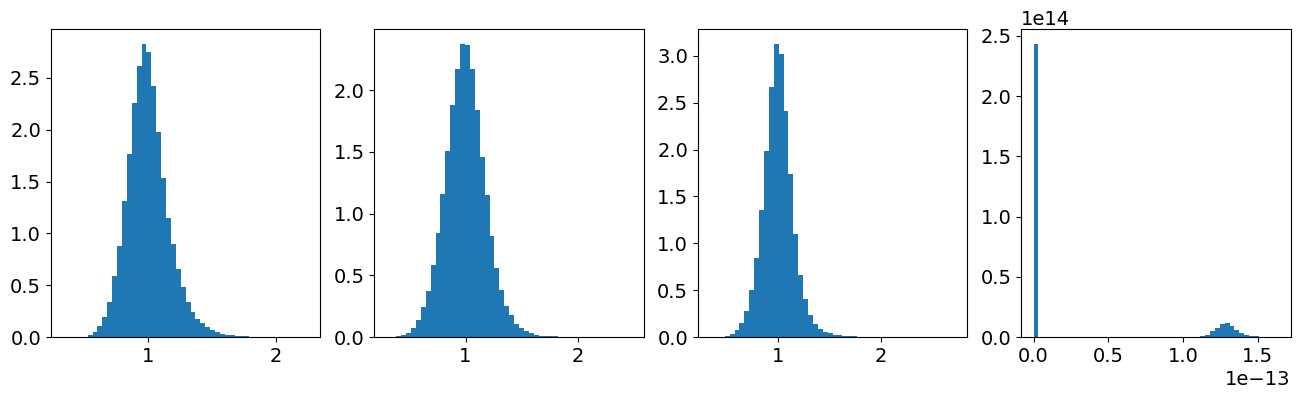

In [8]:
# detrend arrays:
detrended_height = detrend_entire_matrix(height_arr)
detrended_area   = detrend_entire_matrix(area_arr)
detrended_volume = detrend_entire_matrix(volume_arr)

# rescaled_height = (detrended_height / np.ma.mean(detrended_height, axis=0, keepdims=True)).compressed().ravel()
# rescaled_area   = (detrended_area   / np.ma.mean(detrended_area,   axis=0, keepdims=True)).compressed().ravel()
# rescaled_volume = (detrended_volume / np.ma.mean(detrended_volume, axis=0, keepdims=True)).compressed().ravel()

rescaled_height = (height_arr / np.ma.mean(height_arr, axis=0, keepdims=True)).compressed().ravel()
rescaled_area   = (area_arr   / np.ma.mean(area_arr,   axis=0, keepdims=True)).compressed().ravel()
rescaled_volume = (volume_arr / np.ma.mean(volume_arr, axis=0, keepdims=True)).compressed().ravel()

try:
    rescaled_concentration  = (concentration_arr / np.ma.mean(concentration_arr, axis=0, keepdims=True)).compressed().ravel()
except:
    None

# plot for check
fig, ax = plt.subplots(1,4, figsize=(16,4))

# ax[0].hist(height_arr.ravel(), bins=50, density=True)
# ax[0].hist(detrended_height.ravel(), bins=50, density=True)
ax[0].hist(rescaled_height.ravel(), bins=50, density=True)

# ax[1].hist(area_arr.ravel(), bins=50, density=True)
# ax[1].hist(detrended_area.ravel(), bins=50, density=True)
ax[1].hist(rescaled_area.ravel(), bins=50, density=True)

# ax[2].hist(volume_arr.ravel(), bins=50, density=True)
# ax[2].hist(detrended_volume.ravel(), bins=50, density=True)
ax[2].hist(rescaled_volume.ravel(), bins=50, density=True)

try:
    ax[3].hist(concentration_arr.ravel(), bins=50, density=True)
except:
    None

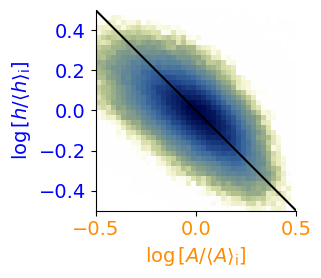

In [28]:
# Plot correlation of h and A
cmap = cm.davos_r 
# cmap = cm.batlowW_r 

fig, ax = plt.subplots(1,1, figsize=(3.5,3))

im = ax.hist2d(np.ma.log(rescaled_area), 
               np.ma.log(rescaled_height), bins=[40,40], density=False, range=[[-.5,.5], [-.5,.5]], cmap=cmap,
               norm=mpl.colors.LogNorm(vmin=20, vmax=2000));

ax.set_aspect("equal")
ax.set(xlabel=r"$\log{[A / \langle A \rangle_{\text{i}}]}$",
       ylabel=r"$\log{[h / \langle h \rangle_{\text{i}}]}$")

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.plot([-.5, .5], [.5, -.5], '-', c="k")
# ax.plot(x, np.log(Vf/np.exp(x)), 'r-')

ax.tick_params(axis='x', labelcolor=A_color)
ax.tick_params(axis='y', labelcolor=h_color)

ax.xaxis.label.set_color(A_color)
ax.yaxis.label.set_color(h_color)
fig.tight_layout()

fig.savefig("figs/Elife/subfigures/hA_correlation.png", dpi=300)


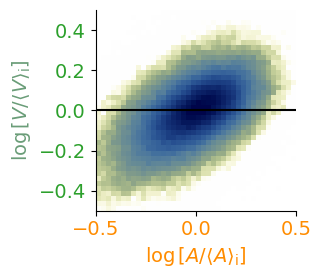

In [34]:
# Plot correlation of V and A
V_color = cm.imola(0.6)

fig, ax = plt.subplots(1,1, figsize=(3.5,3))

ax.hist2d(np.ma.log(rescaled_area), 
          np.ma.log(rescaled_volume), bins=[40,40], density=False, range=[[-.5,.5], [-.5,.5]], cmap=cmap,
          norm=mpl.colors.LogNorm(vmin=20, vmax=2000));

ax.set_aspect("equal")
ax.set(xlabel=r"$\log{[A / \langle A \rangle_{\text{i}}]}$",
       ylabel=r"$\log{[V / \langle V \rangle_{\text{i}}]}$")


ax.tick_params(axis='x', labelcolor=A_color)
ax.tick_params(axis='y', labelcolor="tab:green")

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.plot([-.5, .5], [.0, .0], '-', c="k")
# ax.plot(x, np.log(Vf), 'r-')


ax.xaxis.label.set_color(A_color)
ax.yaxis.label.set_color(V_color)
fig.tight_layout()


fig.savefig("figs/Elife/subfigures/VA_correlation.png", dpi=300)

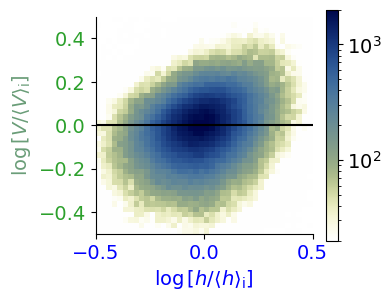

In [35]:
# Plot correlation of V and h

fig, ax = plt.subplots(1,1, figsize=(3.5,3))

im=ax.hist2d(np.ma.log(rescaled_height), 
          np.ma.log(rescaled_volume), bins=[40,40], density=False, range=[[-.5,.5], [-.5,.5]], cmap=cmap,
          norm=mpl.colors.LogNorm(vmin=20, vmax=2000));

ax.set_aspect("equal")
ax.set(xlabel=r"$\log{[h / \langle h \rangle_{\text{i}}]}$",
       ylabel=r"$\log{[V / \langle V \rangle_{\text{i}}]}$")


ax.tick_params(axis='x', labelcolor=h_color)
ax.tick_params(axis='y', labelcolor="tab:green")
ax.plot([-.5, .5], [-.0, .0], '-', c="k")
# ax.plot(np.log(Vf/np.exp(x)), np.log(Vf), 'r-')

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

ax.xaxis.label.set_color(h_color)
ax.yaxis.label.set_color(V_color)
fig.savefig("figs/Elife/subfigures/Vh_correlation.png", dpi=300)


fig.colorbar(im[3], ax=ax)
fig.savefig("figs/Elife/subfigures/Vh_correlation_with_colorbar.svg", dpi=300)


In [12]:
corr_coeffs_hA = sc.stats.pearsonr(rescaled_area, rescaled_height)[0]
corr_coeffs_VA = sc.stats.pearsonr(rescaled_area,   rescaled_volume)[0]
corr_coeffs_Vh = sc.stats.pearsonr(rescaled_height, rescaled_volume)[0]

print(f"Pearson correlation coefficients:\nhA = {corr_coeffs_hA:0.2f}\nVA = {corr_coeffs_VA:0.2f}\nVh = {corr_coeffs_Vh:0.2f}")

Pearson correlation coefficients:
hA = -0.62
VA = 0.53
Vh = 0.31


### PDFs of standard deviation

In [13]:
area   = ((area_arr   / np.ma.mean(area_arr,   axis=(0,1), keepdims=True)).compressed()).ravel()
height = ((height_arr / np.ma.mean(height_arr, axis=(0,1), keepdims=True)).compressed()).ravel()
volume = ((volume_arr / np.ma.mean(volume_arr, axis=(0,1), keepdims=True)).compressed()).ravel()

x_A, y_A = compute_pdf_from_bins(area,   scale_to_int=20, sigma=1)
x_h, y_h = compute_pdf_from_bins(height, scale_to_int=20, sigma=1)
x_V, y_V = compute_pdf_from_bins(volume, scale_to_int=20, sigma=1)

mass_arr = np.ma.concatenate([(concentration_list[-1] * volume_list[-1]).T,
                              (concentration_list[-2] * volume_list[-2]).T]).T

mass = ((mass_arr / np.ma.mean(mass_arr, axis=(0,1), keepdims=True)).compressed()).ravel()
x_M, y_M =  compute_pdf_from_bins(mass, scale_to_int=20, sigma=1)


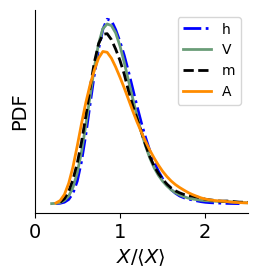

In [14]:
lw = 2
fig, ax = plt.subplots(1,1, figsize=(2.8,3))

ax.plot(x_h, y_h, c=h_color, lw=lw, ls='-.', label=r"h")
ax.plot(x_V, y_V, c=V_color, lw=lw, ls='-',  label=r"V")
ax.plot(x_M, y_M, c=c_color, lw=lw, ls="--", label=r"m")
ax.plot(x_A, y_A, c=A_color, lw=lw, ls='-',  label=r"A")

ax.set(xlabel=r"$X/\langle X \rangle$", 
       ylabel="PDF",
       xscale="linear",
       yscale="linear",
       xlim=(0, 2.5));

ax.set_yticks([])
ax.legend(prop={'size': 10}, handlelength=2, handleheight=1)

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
fig.tight_layout()
fig.savefig("figs/Elife/subfigures/hAVv_SD_distribution.svg")